In [1]:
# run_evaluation(
#     scaled_env: gym.Env,
#     model: BaseAlgorithm,
#     is_masked: bool = True,
#     number_of_episodes: int = 1
# )

"""
TODO: Van heuristiek een BaseAlgorithm maken
Dat werkt op een gym.Env speciaal voor dat algo"""

'\nTODO: Van heuristiek een BaseAlgorithm maken\nDat werkt op een gym.Env speciaal voor dat algo'

In [1]:
%load_ext autoreload
%autoreload 2

# Global Arguments
RAW_DATA_LOCATION = '../../../data/2025_minute.csv'
CLEANED_DATA_LOCATION = '../../../data/2025_minute_cleaned_with_val'

In [2]:
# Imports
import pandas as pd
import numpy as np
import gymnasium as gym
from Simulation.suite_simple_trading.data_splitting import get_or_create_train_val_test_split
from Simulation.suite_simple_trading.pre_processing import clean_data
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute
from Simulation.suite_simple_trading.metrics import print_agent_performance



In [3]:
# Load in data
raw_data = pd.read_csv(RAW_DATA_LOCATION, sep=';')
cleaned_data = clean_data(raw_data)
all_data = cleaned_data[['Datetime', 'Imbalance Price']]

train_df, val_df_episodes, test_df_episodes = get_or_create_train_val_test_split(
    all_data=all_data,
    save_path=CLEANED_DATA_LOCATION,
    days_per_episode=3,
    test_fraction=0.2,
    val_fraction=0.1,
    min_spacing_days=3,
    exclusion_hours=4
)

Data successfully verified to start on a quarter hour.
--- Loading existing split from '../../../data/2025_minute_cleaned_with_val' ---
Data loaded successfully.
Train: 69.0%, Val: 10.7%, Test: 20.3%
Episodes -> Val: 10, Test: 19


In [4]:
class QuarterlyTrendDecisionMaker:
    """
    A decision maker that implements the quarterly trend-based heuristic policy.
    It waits for a signal within a quarter and then locks in the decision for the
    remainder of that quarter.
    """

    def __init__(self, theta_buy: float, theta_sell: float, env: gym.Env):
        """
        Initializes the decision maker with its specific parameters.

        Args:
            theta_buy: The price threshold for buying/charging.
            theta_sell: The price threshold for selling/discharging.
            past_prices_needed: The number of historical prices required for the trend analysis.
        """
        self.theta_buy = theta_buy
        self.theta_sell = theta_sell
        self.past_prices_needed = env.number_of_past_prices
        self.env = env

        # Internal state for the manager logic
        self.quarterly_decision = 0  # 0: Idle, 1: Charge, 2: Discharge
        self.decision_made_this_quarter = False

        # Extra data needed
        datetime_index = pd.to_datetime(env.all_data['Datetime'], utc=True)
        self.minutes = datetime_index.dt.minute.to_numpy()

    def reset(self):
        """
        Resets the internal state of the decision maker for a new episode.
        """
        self.quarterly_decision = 0
        self.decision_made_this_quarter = False

    def get_action(self, observation: np.ndarray) -> int:
        """
        The main method called by the runner to get the next action.
        It contains the full quarterly manager logic.

        Args:
            observation: The current state observation from the environment.

        Returns:
            The integer action to be taken.
        """
        current_minute = self.minutes[self.env.current_step]
        current_minute_of_quarter = current_minute % 15

        # --- Quarterly Reset Logic ---
        if current_minute_of_quarter == 0:
            self.quarterly_decision = 0
            self.decision_made_this_quarter = False

        # --- Decision Making Logic ---
        if not self.decision_made_this_quarter:

            # This is the actual heuristic policy logic
            policy_action = self._trend_based_heuristic(observation)

            if policy_action != 0:  # 0 is the Idle action
                self.quarterly_decision = policy_action
                self.decision_made_this_quarter = True

        return self.quarterly_decision

    def _trend_based_heuristic(self, observation: np.ndarray) -> int:
        """
        Private method containing the core trend-based policy.
        (This is your old 'trend_based_heuristic_policy' function, now inside the class)
        """
        current_price = observation[1]  # Assumes price is the second element
        price_history = observation[-self.past_prices_needed:]  # Assumes history is at the end

        ACTION_IDLE = 0
        ACTION_CHARGE = 1
        ACTION_DISCHARGE = 2

        # Example trend check: are the last 3 prices negative?
        is_buy_trend = all(p < 0 for p in price_history[-3:])
        if current_price <= self.theta_buy and is_buy_trend:
            return ACTION_CHARGE

        # Example trend check: are the last 3 prices positive?
        is_sell_trend = all(p > 0 for p in price_history[-3:])
        if current_price >= self.theta_sell and is_sell_trend:
            return ACTION_DISCHARGE

        return ACTION_IDLE

In [5]:
# Environment
class HeuristicEnv(gym.Env):
    def __init__(
            self,
            battery_capacity_mwh: float,
            charge_discharge_rate_mw: float,
            all_data: pd.DataFrame,
            number_of_past_prices: int = 5
    ):
        super().__init__()

        self.battery_capacity_mwh = battery_capacity_mwh
        self.time_interval = 1 / 60
        self.charge_discharge_rate = charge_discharge_rate_mw
        self.all_data = all_data
        self.prices = all_data['Imbalance Price'].to_numpy()
        self.number_of_past_prices = number_of_past_prices
        self.total_energy_traded_per_quarter = 0

        self.max_steps = len(self.prices)

        # SoC, last price, number of past prices
        num_of_dim = 1 + 1 + self.number_of_past_prices
        low_bounds = np.concatenate([
            np.array([0.0], dtype=np.float32),
            np.array([-np.inf] * (1 + self.number_of_past_prices), dtype=np.float32)
        ])
        high_bounds = np.concatenate([
            np.array([battery_capacity_mwh], dtype=np.float32),
            np.array([np.inf] * (1 + self.number_of_past_prices), dtype=np.float32)
        ])
        self.observation_space = gym.spaces.Box(
            low=low_bounds, high=high_bounds, shape=(num_of_dim,), dtype=np.float32
        )

        # --- STATE INITIALIZATION ---
        self.current_step = 0
        self.soc_mwh = 0.0

    def _get_power_rate_from_action(self, action: int) -> float:
        """
        Abstract method: Subclasses MUST implement this to translate an action
        into a power rate (in MW).
        """
        if action == 0:  # Idle
            return 0.0
        elif action == 1:  # Charge
            return self.charge_discharge_rate
        elif action == 2:  # Discharge
            return -self.charge_discharge_rate

    def get_idle_action(self) -> int:
        """
        Abstract method: Subclasses MUST implement this to return the action
        corresponding to 'Idle' (no charge/discharge).
        """
        raise NotImplementedError("This method must be implemented by the subclass.")

    def _get_observation(self) -> np.ndarray:
        """
        Constructs the observation array: [SoC, Past Prices..., Current Price]
        If there is insufficient history, past prices are padded with 0.
        """
        # 1. State of Charge
        soc_obs = np.array([self.soc_mwh], dtype=np.float32)

        # 2. Prices (History + Current)
        # Determine the range of prices to fetch
        start_index = self.current_step - self.number_of_past_prices
        end_index = self.current_step + 1  # +1 because slicing is exclusive at the end

        # Handle the start of the simulation (padding needed)
        if start_index < 0:
            # Get available prices from index 0 to current
            available_prices = self.prices[0:end_index]

            # Calculate how many zeros we need
            padding_count = abs(start_index)
            padding = np.zeros(padding_count, dtype=np.float32)

            # Combine padding + available prices
            price_obs = np.concatenate([padding, available_prices])
        else:
            # We have enough history, just slice
            price_obs = self.prices[start_index:end_index]

        # 3. Combine SoC and Prices
        return np.concatenate([soc_obs, price_obs]).astype(np.float32)

    def _calculate_delayed_reward(self):
        # Reward based on price at the end of a quarter, this is also what businesses have to pay
        return -self.prices[self.current_step] * self.total_energy_traded_per_quarter if self.all_data['Datetime'][self.current_step].minute % 15 == 14 else 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.soc_mwh = 0.0

        obs = self._get_observation()
        info = {}
        return obs, info

    def step(self, action: int):
        if self.all_data['Datetime'][self.current_step].minute % 15 == 0:
            self.total_energy_traded_per_quarter = 0.0

        # Get power rate from the specific policy implementation
        x_t = self._get_power_rate_from_action(action)

        energy_traded = x_t * self.time_interval

        if energy_traded > 0:
            actual_energy_traded = min(energy_traded, self.battery_capacity_mwh - self.soc_mwh)
        elif energy_traded < 0:
            actual_energy_traded = max(energy_traded, -self.soc_mwh)
        else:
            actual_energy_traded = 0.0

        self.soc_mwh += actual_energy_traded
        self.total_energy_traded_per_quarter += actual_energy_traded

        reward = self._calculate_delayed_reward()

        terminated = self.current_step + 1 >= self.max_steps
        obs = self._get_observation() if not terminated else self.observation_space.sample()
        info = {'energy_charged_discharged': actual_energy_traded}

        self.current_step += 1

        return obs, reward, terminated, False, info

In [6]:
# Grid search for best hyperparameter (theta_buy/theta_sell)

In [26]:
# Simulation
reward_over_episodes = 0
history_df = {
    'soc' : [],
    'prices': [],
    'energy_charged_discharged' : [],
    'real_rewards': []
}
for i, episode in enumerate(test_df_episodes):
    env = HeuristicEnv(
        10,
        4,
        episode,
    )
    decision_maker = QuarterlyTrendDecisionMaker(
        50,
        150,
        env
    )
    env.reset()
    obs = env.observation_space.sample()

    print(f'Starting episode {i}')
    terminated = False
    total_reward = 0
    while not terminated:
        action = decision_maker.get_action(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        history_df['soc'].append(obs[0])
        history_df['prices'].append(obs[1])
        history_df['energy_charged_discharged'].append(info['energy_charged_discharged'])
        history_df['real_rewards'].append(reward) #Added so the print_agent_performance() works at the end
        total_reward += reward
    print(f'Total reward this episode is {total_reward}')
    reward_over_episodes += total_reward
    env.reset()

print(f'Total reward this test is {reward_over_episodes}')



Starting episode 0
Total reward this episode is 874.4783333333335
Starting episode 1
Total reward this episode is 5363.426066666676
Starting episode 2
Total reward this episode is 5065.253866666671
Starting episode 3
Total reward this episode is 257.91286666666673
Starting episode 4
Total reward this episode is 9402.100400000012
Starting episode 5
Total reward this episode is 3653.9038666666675
Starting episode 6
Total reward this episode is 4100.800799999999
Starting episode 7
Total reward this episode is 4066.178800000002
Starting episode 8
Total reward this episode is 2.4470000000000107
Starting episode 9
Total reward this episode is 3052.0902666666743
Starting episode 10
Total reward this episode is 3891.8887333333373
Starting episode 11
Total reward this episode is 2864.055933333336
Starting episode 12
Total reward this episode is 989.840533333336
Starting episode 13
Total reward this episode is 4186.790666666676
Starting episode 14
Total reward this episode is 4743.470866666667
S


KeyboardInterrupt

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 
Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x78a7b97c0360>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 370, in remove
    self = selfref()
           ^^^^^^^^^
KeyboardInterrupt: 
Exception ignored in sys.unraisablehook: <built-in function unraisablehook>
Traceback (most recent call last):
  File "/home/lander/Documents/school/Thesis/ThesisGit/.venv/lib/python3.12/site-packages/ipykernel/iostream.py", line 604, in flush
  File "/usr/lib/python3.12/threading.py", line 655, in wait
    signaled = self._cond.wait(timeout)
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/threading.py", line 359, in wait
    gotit = waiter.acquire(True, timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^

Saving plot to: plots/test_reward_shaping_action_penalty


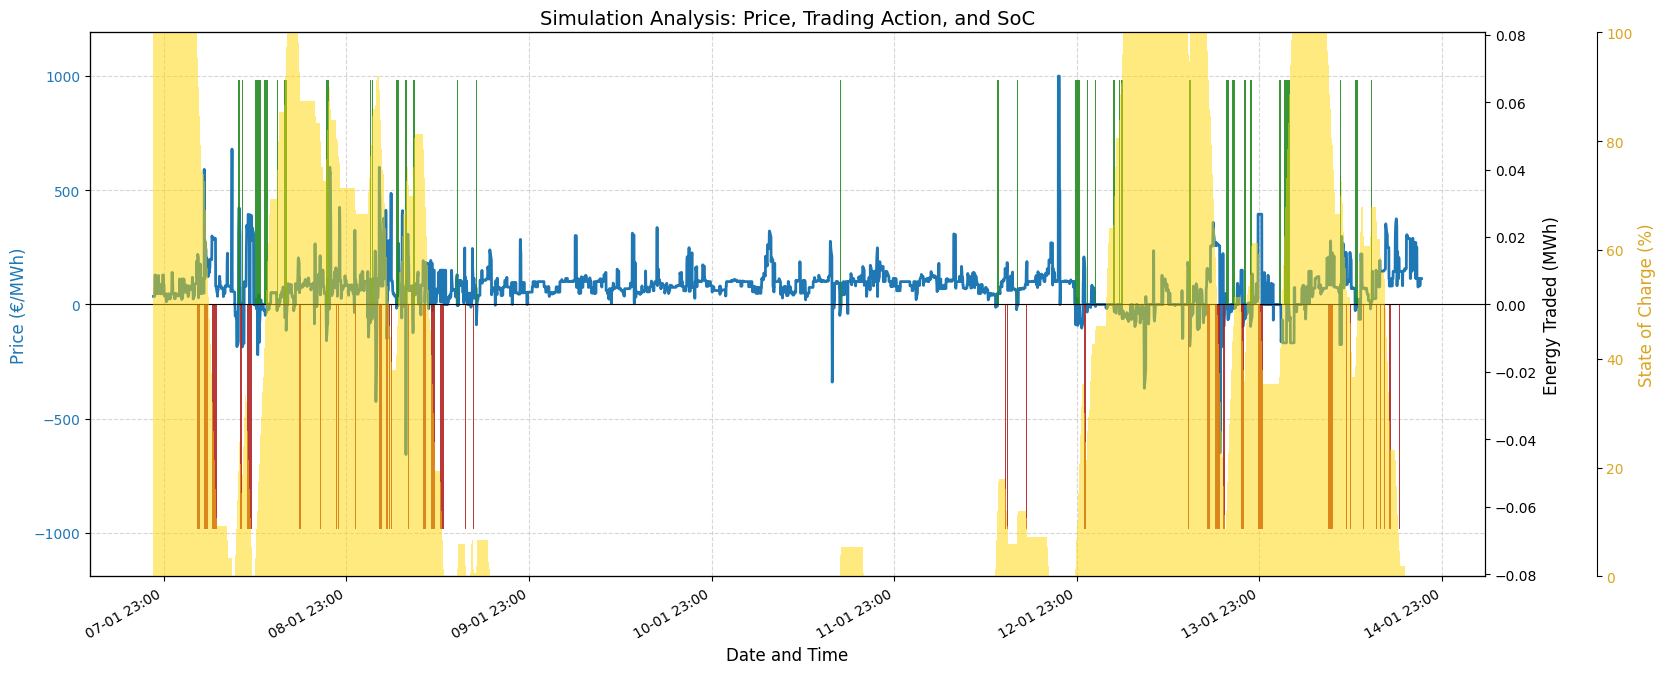

In [25]:


results = pd.DataFrame(history_df)
results['Datetime'] = pd.to_datetime(all_data['Datetime'])
plot_simulation_results_minute_by_minute(
    results,
    "test_reward_shaping_action_penalty",
    10_000,
    20_000
)

In [30]:
from Simulation.suite_simple_trading.metrics import amount_of_good_quarters, amount_of_bad_quarters, good_quarter_ratio, \
    mean_reward_per_quarter, bad_quarter_started_good, mean_daily_reward, profit_per_battery_cycle, battery_cycle_count

print(amount_of_good_quarters(results))
print(amount_of_bad_quarters(results))
print(good_quarter_ratio(results))
print(mean_reward_per_quarter(results))
#trap_quarters = bad_quarter_started_good(results)
print(mean_daily_reward(results))
print(profit_per_battery_cycle(results))
print(battery_cycle_count(results))

410
111
0.7869481765834933
62.92524952015359
1110.229597668208
1537.4293450064854
41.12000000000002
